In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skfmm
import os
import requests
import io
from tqdm.notebook import tqdm

In [2]:
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = (4, 4)

In [42]:
import json

# Load the prior 3D models: 400 samples

It will take about 1min to load the ensemble of prior state model file, ~1.2GB

In [3]:
# load the prior state
# t = time.time()
response = requests.get('https://www.dropbox.com/scl/fi/hpcvabrr8sv0l8z344zy7/results_ensmeble_04032024.npy?rlkey=aqrrpr9qtlr163svdut3rmwco&dl=1')
response.raise_for_status()
m_ensemble = (np.load(io.BytesIO(response.content))>=0)*1
# print(time.time() - t)

In [5]:
m_ensemble.shape

(400, 384000)

In [4]:
np.sum(m_ensemble)

4519937

`m_ensemble`: the ensemble of prior state models. 
- It has totally 400 realizations, each model has 384000 (80x80x60) dimesnions 
- each model dimension is 80(X_dim) x 80(Y_dim) x 60(Z_dim)
- 1: is the intrusion model; 0: is the host rock


In [5]:
# total number of prior model realizations
n_reals = m_ensemble.shape[0]

Plot the samples of the prior model ensemble

In [19]:
m_sdf = skfmm.distance(m_ensemble[0].reshape(x_dim,y_dim,z_dim)-0.5)
plt_contour = np.argwhere((m_sdf<2) & (m_sdf>=-0.5))

In [29]:
np.sum(m_sdf >= -0.5)

13797

In [30]:
X = m_ensemble[0].reshape(x_dim,y_dim,z_dim)

In [35]:
np.sum(X)

10901

In [24]:
np.sum(m_ensemble[0])

10901

In [21]:
np.sum(m_sdf)

-8691406.491106465

In [20]:
np.sum(plt_contour[:,0])

346544

0
346544
(8739, 3)
1
364370
(9088, 3)
2
364370
(9088, 3)
3
363402
(9038, 3)


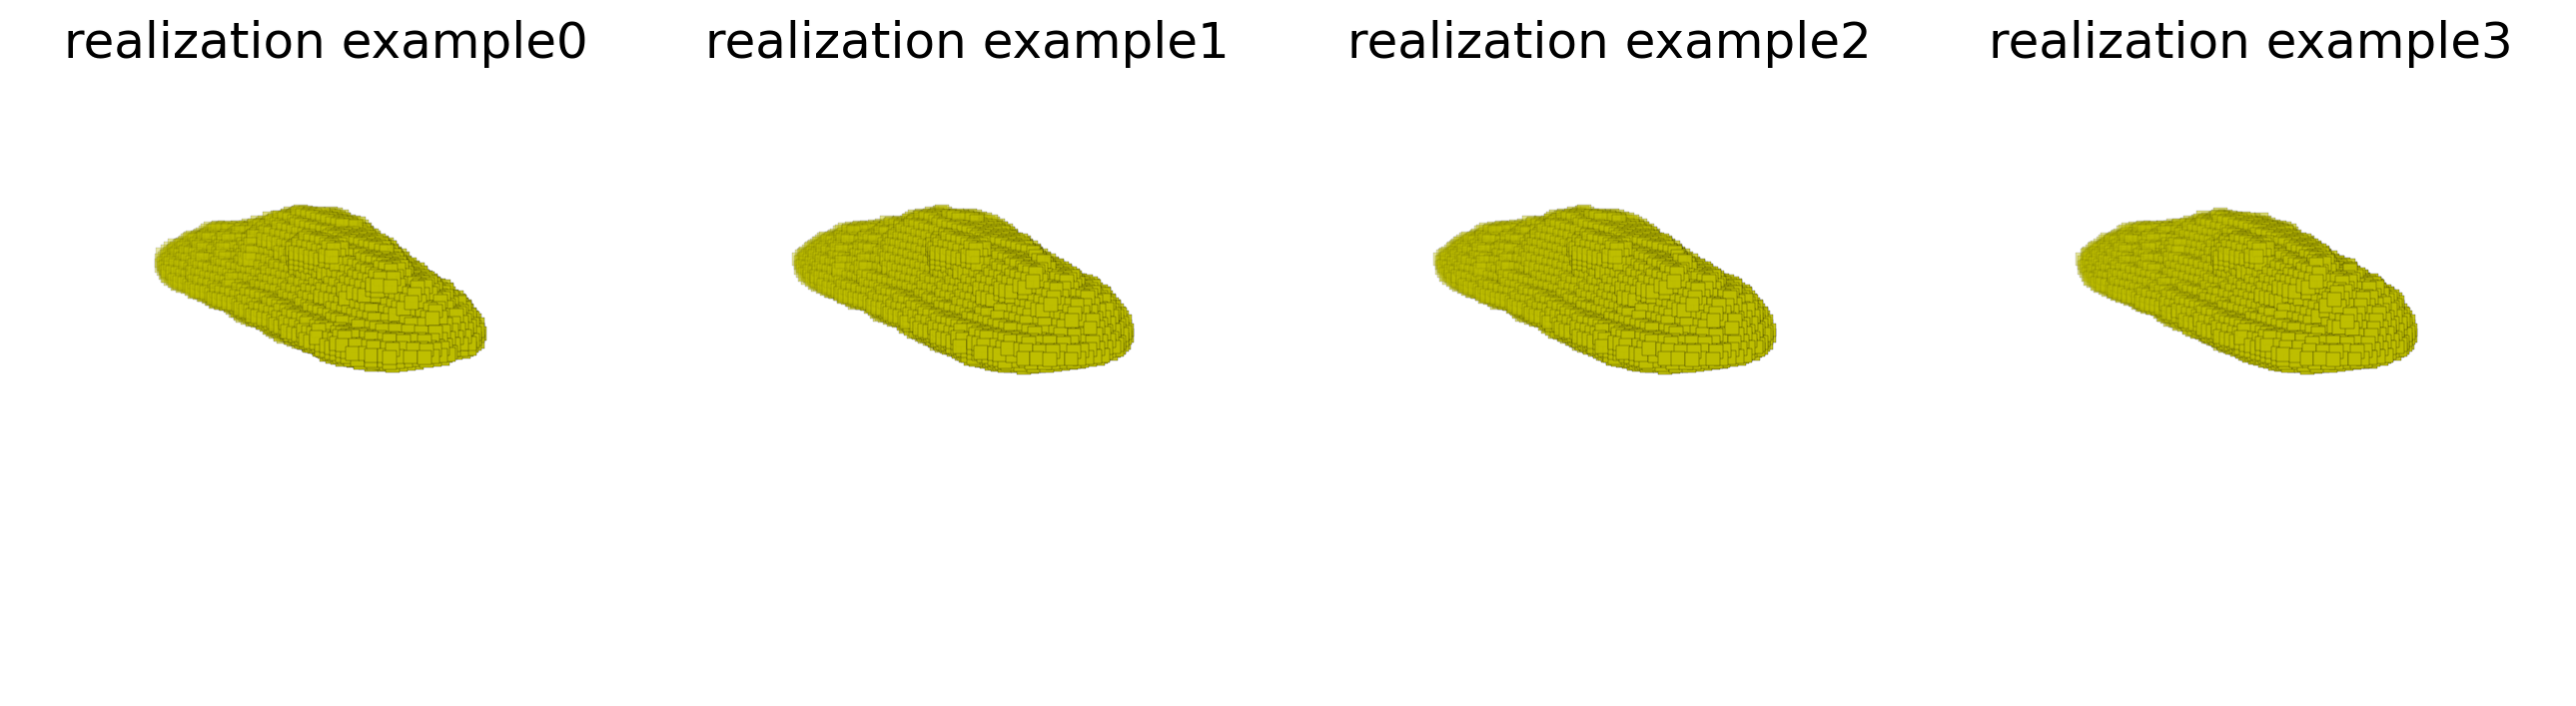

In [18]:
figs = plt.figure(figsize=(13,7))
for i in range(4):
    print(i)
    # calcuate the signed distance for visualization
    m_sdf = skfmm.distance(m_ensemble[i].reshape(x_dim,y_dim,z_dim)-0.5)
    plt_contour = np.argwhere((m_sdf<2) & (m_sdf>=-0.5))
    print(np.sum(plt_contour[:,0]))
    print(plt_contour.shape)
    ax = figs.add_subplot(1,4,i+1, projection='3d')
    ax.scatter(plt_contour[:,0], 
               plt_contour[:,1],
               plt_contour[:,2], 
               c = 'y',
               linewidth=0.1,edgecolor='k',
               marker='s', vmax=1,
               s=25)
    ax.set_title('realization example'+str(i), fontsize=18)
    ax.set_xlim(10, m_sdf.shape[0]-5), ax.set_ylim(5, m_sdf.shape[1]-5), ax.set_zlim(5,m_sdf.shape[2]-5)
    ax.set_axis_off()
    ax.set_facecolor('w')
plt.tight_layout()

# Load the additional 600 geological belief models

In [3]:
# load the prior state
# t = time.time()
response = requests.get('https://www.dropbox.com/scl/fi/uecu1to6tj06pztav762i/results_ensmeble_06022024.npy?rlkey=52dtasucqs6zvq6c1hux31tvz&dl=1')
response.raise_for_status()
m_ensemble = (np.load(io.BytesIO(response.content))>=0)*1
# print(time.time() - t)

# Load the corresponding Moun data at each sensors

In [36]:
# name muon observation data as var d_muon
d_fname = 'muon/real_'

In [37]:
# extract muon observation data for each sensor 
sensor_num = 5 # sensor index

In [40]:
d_ensemble = []
for i in range(m_ensemble.shape[0]):
    d_ensemble.append(m_ensemble[i])

(384000,)

In [44]:
# Load the corresponding Moun data. 400 realizations for the 400 3D models.
with open(d_fname+str(0)+'.json', 'r') as read_file:
    d_muon = json.loads(read_file.read())
keys = list(d_muon)[sensor_num]

d_ensemble = []
for i in range(n_reals):
    with open(d_fname+str(i)+'.json', 'r') as read_file:
        loaded_dictionaries = json.loads(read_file.read())
    d_ensemble.append(loaded_dictionaries[keys])
d_ensemble = np.asarray(d_ensemble)

# Perform PCA on the Moun data of each sensor

In [64]:
from sklearn.decomposition import PCA

# Scree plot
d_pca = PCA(n_components=100, svd_solver='full')
d_pca.fit(d_ensemble)
d_pcscr = d_pca.transform(d_ensemble) # use all the PCs

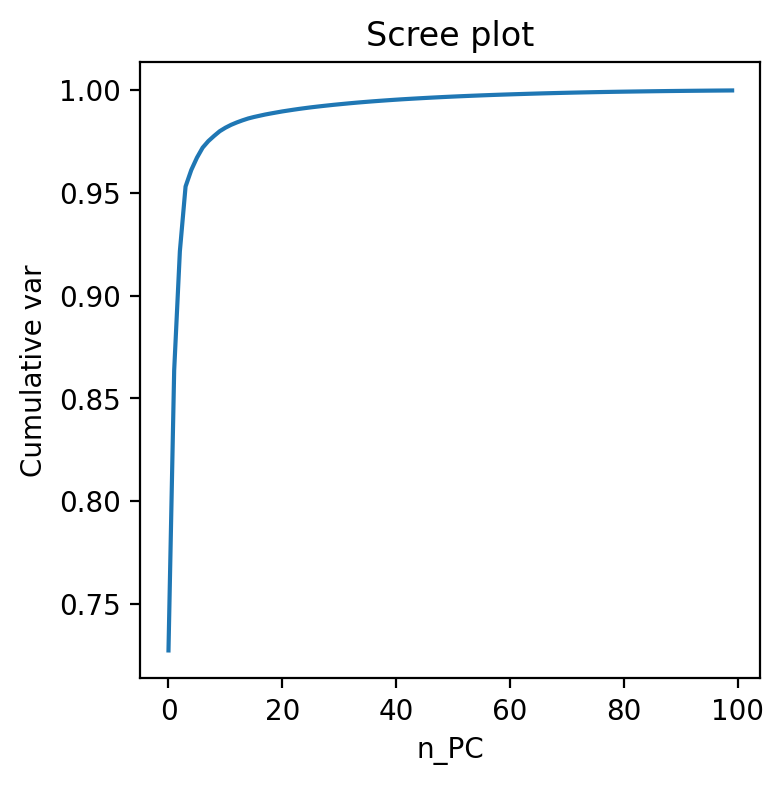

In [54]:
plt.plot(d_pca.explained_variance_ratio_.cumsum())
plt.title('Scree plot'); plt.ylabel('Cumulative var'); plt.xlabel('n_PC')
plt.show()

In [68]:
retain_var = 98 # %
d_keepPCs = np.argmin(abs(d_pca.explained_variance_ratio_.cumsum()-retain_var*0.01))
d_pcscr = d_pcscr[:,:d_keepPCs]

In [69]:
np.sum(d_pcscr)

1.8590071704238653e-09

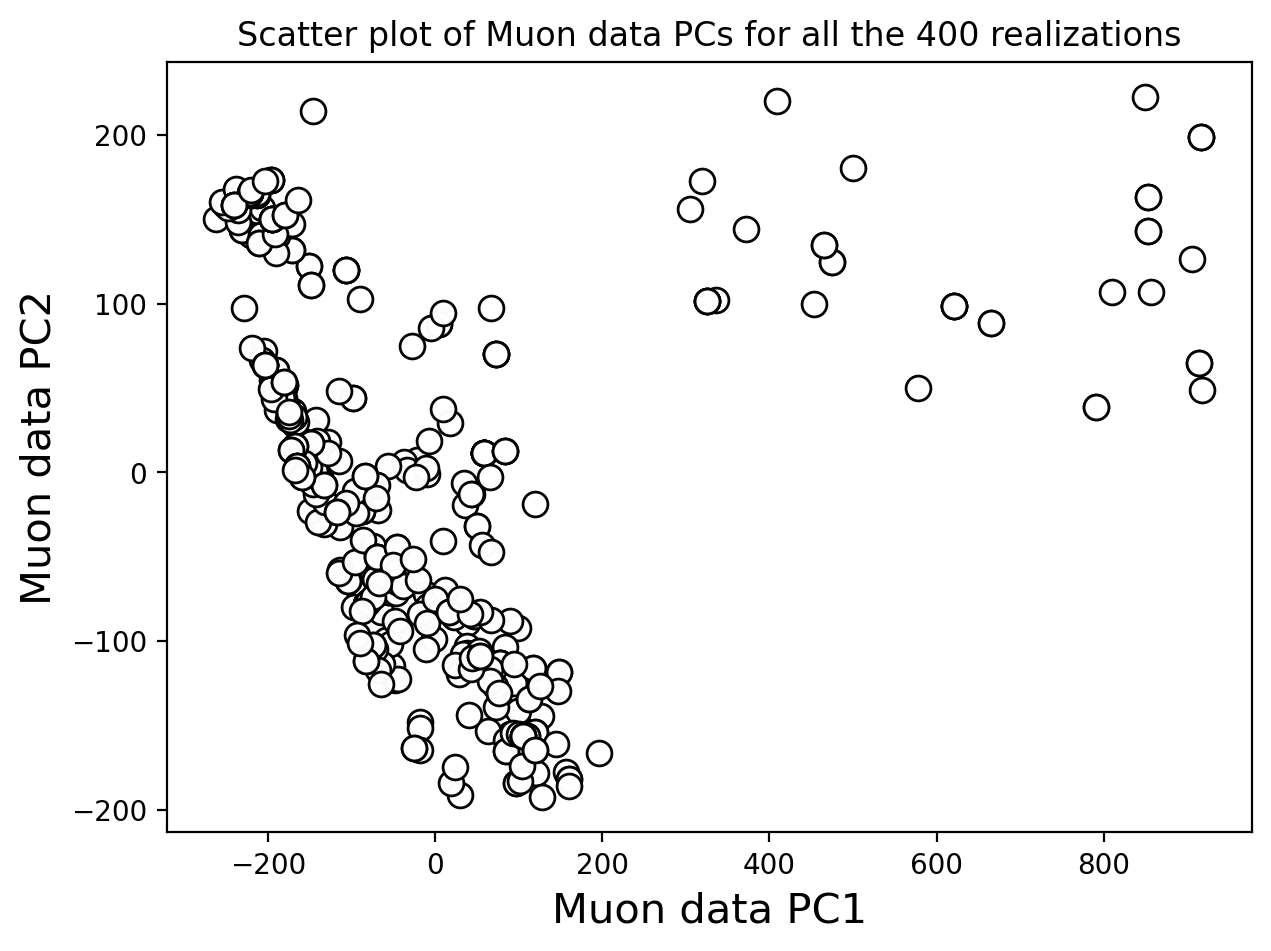

In [57]:
pcnum = 1
plt.figure(figsize=(7,5))
plt.scatter(d_pcscr[:,pcnum-1], d_pcscr[:,pcnum],alpha=0.98, 
            s=80, facecolor='w',
#                 vmax=0.08, 
            edgecolors='k', linewidth=1)
plt.xlabel('Muon data PC'+str(pcnum), fontsize=15)
plt.ylabel('Muon data PC'+str(pcnum+1), fontsize=15)
plt.title('Scatter plot of Muon data PCs for all the 400 realizations')
plt.show()

# Load Ground Truth

In [ ]:
# load ground model
response = requests.get('https://www.dropbox.com/scl/fi/yt4d3xb3mj5v00trnhx3u/ground_truth_80x80x60.npy?rlkey=qo6hrni4sidp9nryy234g8zq5&dl=1')
response.raise_for_status()
true_intrusion = np.load(io.BytesIO(response.content))
# load topography
response = requests.get('https://www.dropbox.com/scl/fi/lua5fwx9dwejml14u3bxp/topography.npy?rlkey=2mrl452k7u0ubn0vwzfp61gm6&dl=1')
response.raise_for_status()
topography = np.load(io.BytesIO(response.content))*10
# dimension of the mesh
x_dim, y_dim, z_dim = true_intrusion.shape
# size of the mesh grid
hx, hy, hz = 50, 50, 10 # meters

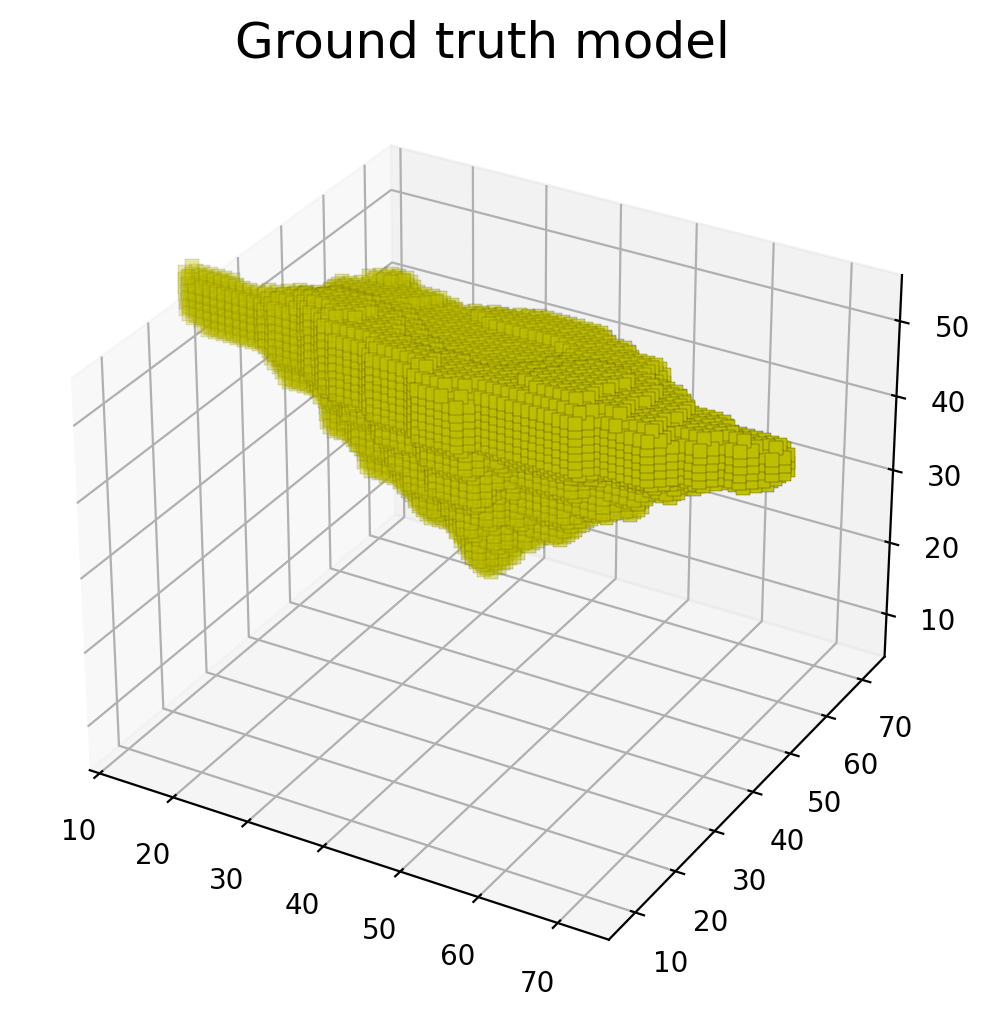

In [ ]:
# calcuate the signed distance for visualization
m_sdf = skfmm.distance(true_intrusion-0.5)
plt_contour = np.argwhere((m_sdf<2) & (m_sdf>=-0.5))
figs = plt.figure(figsize=(7,6))
ax = figs.add_subplot(1,1,1, projection='3d')
ax.scatter(plt_contour[:,0], 
           plt_contour[:,1],
           plt_contour[:,2], 
           c = 'y',
           linewidth=0.1,edgecolor='k',
           marker='s', vmax=1,
           s=25)
ax.set_title('Ground truth model', fontsize=18)
ax.set_xlim(10, m_sdf.shape[0]-5), ax.set_ylim(5, m_sdf.shape[1]-5), ax.set_zlim(5,m_sdf.shape[2]-5)
plt.show()